### COMP 5630 - Final Project
#### Group Members: Cindy Jiang, Hillary Lopez, and Trisha Balamurugan

#### Project Overview
This project focuses on multi-class classification of music genres using the Spotify Tracks dataset. The goal is to evaluate how well machine learning models can predict a song’s genre based on numerical audio features such as danceability, energy, and tempo.

We will implement and compare models including Logistic Regression, Random Forest, and Support Vector Machines (SVM). Our approach includes data preprocessing, feature scaling, and model tuning. Performance will be evaluated using metrics such as accuracy and F1-score to determine the most effective model.

In [1]:
# Install if needed
!pip install imbalanced-learn

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/spotify-tracks-genre-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.17M/8.17M [00:00<00:00, 146MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/spotify-tracks-genre-dataset/versions/1


In [3]:
import os
import pandas as pd

# Path to the dataset
dataset_path = "/root/.cache/kagglehub/datasets/thedevastator/spotify-tracks-genre-dataset/versions/1"
csv_file = os.path.join(dataset_path, "train.csv")

# Load the dataset
df = pd.read_csv(csv_file)

# Quick look at the data
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

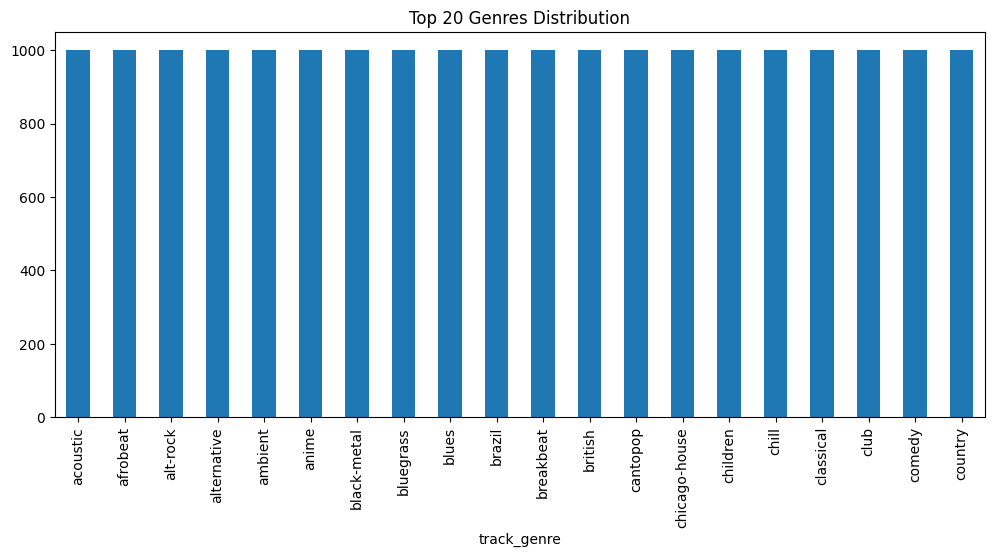

In [4]:
# Check dataset info
df.info()

# Check for missing values
print(df.isnull().sum())

# Check genre distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
df['track_genre'].value_counts().head(20).plot(kind='bar')
plt.title("Top 20 Genres Distribution")
plt.show()

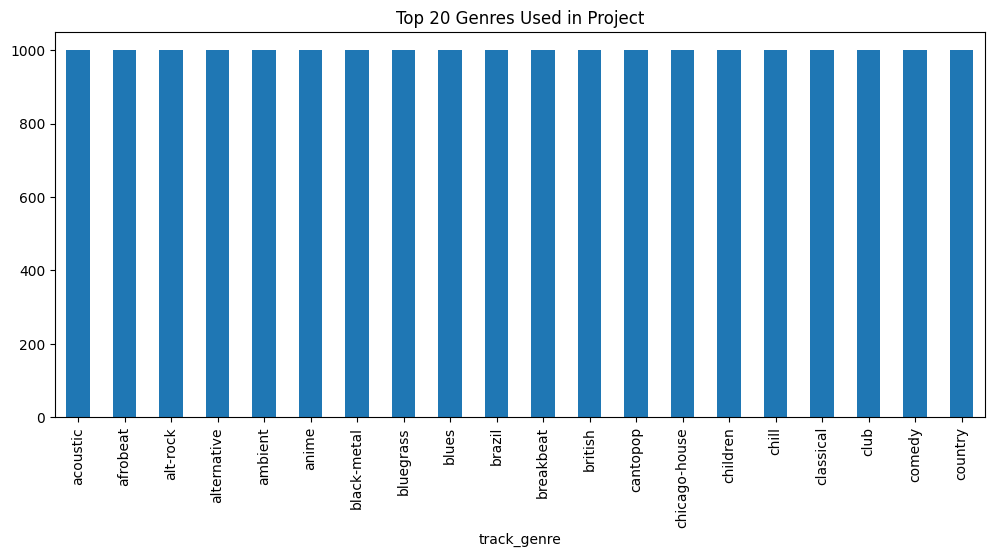

Preprocessing complete! ✅
Number of genres used: 20
Training set size: (16000, 9)
Test set size: (4000, 9)


In [5]:
# 1. Remove duplicates
df = df.drop_duplicates()

# 2. Drop missing values
df = df.dropna()

# 3. Keep only the top 20 most common genres
top_genres = df['track_genre'].value_counts().head(20).index
df = df[df['track_genre'].isin(top_genres)]

# 4. Check updated genre distribution
plt.figure(figsize=(12,5))
df['track_genre'].value_counts().plot(kind='bar')
plt.title("Top 20 Genres Used in Project")
plt.show()

# 5. Select numerical audio features
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo'
]
X = df[features]

# 6. Encode genre labels
le = LabelEncoder()
y = le.fit_transform(df['track_genre'])

# 7. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 8. Standardize features for Logistic Regression and SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Preprocessing complete! ✅")
print("Number of genres used:", len(top_genres))
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

In [6]:
# Baseline model
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_dummy)
baseline_f1 = f1_score(y_test, y_pred_dummy, average='macro')

print("Baseline Accuracy:", baseline_acc)
print("Baseline Macro F1:", baseline_f1)

Baseline Accuracy: 0.05
Baseline Macro F1: 0.0047619047619047615


In [7]:
# Logistic Regression
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')

print("Logistic Regression Accuracy:", lr_acc)
print("Logistic Regression Macro F1:", lr_f1)
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 0.3705
Logistic Regression Macro F1: 0.34749204237371245
               precision    recall  f1-score   support

     acoustic       0.23      0.23      0.23       200
     afrobeat       0.28      0.31      0.29       200
     alt-rock       0.19      0.30      0.23       200
  alternative       0.16      0.16      0.16       200
      ambient       0.48      0.52      0.50       200
        anime       0.08      0.01      0.03       200
  black-metal       0.62      0.81      0.70       200
    bluegrass       0.38      0.48      0.43       200
        blues       0.16      0.07      0.10       200
       brazil       0.27      0.17      0.20       200
    breakbeat       0.42      0.46      0.44       200
      british       0.10      0.03      0.04       200
     cantopop       0.30      0.42      0.35       200
chicago-house       0.51      0.72      0.60       200
     children       0.29      0.35      0.32       200
        chill       0.38      0.

In [8]:
# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')

print("Random Forest Accuracy:", rf_acc)
print("Random Forest Macro F1:", rf_f1)
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.4865
Random Forest Macro F1: 0.48028585899207255
               precision    recall  f1-score   support

     acoustic       0.34      0.30      0.32       200
     afrobeat       0.40      0.51      0.45       200
     alt-rock       0.14      0.16      0.15       200
  alternative       0.28      0.23      0.26       200
      ambient       0.50      0.61      0.55       200
        anime       0.42      0.34      0.38       200
  black-metal       0.77      0.86      0.81       200
    bluegrass       0.47      0.59      0.53       200
        blues       0.40      0.33      0.36       200
       brazil       0.32      0.32      0.32       200
    breakbeat       0.62      0.58      0.60       200
      british       0.27      0.14      0.18       200
     cantopop       0.42      0.55      0.48       200
chicago-house       0.70      0.77      0.73       200
     children       0.51      0.43      0.47       200
        chill       0.45      0.50      0.47

In [9]:
# Support Vector Machine
svm = SVC()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')

print("SVM Accuracy:", svm_acc)
print("SVM Macro F1:", svm_f1)
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

SVM Accuracy: 0.41225
SVM Macro F1: 0.3991785877582166
               precision    recall  f1-score   support

     acoustic       0.28      0.29      0.29       200
     afrobeat       0.31      0.33      0.32       200
     alt-rock       0.20      0.38      0.26       200
  alternative       0.16      0.10      0.12       200
      ambient       0.46      0.51      0.49       200
        anime       0.35      0.19      0.25       200
  black-metal       0.67      0.81      0.73       200
    bluegrass       0.44      0.46      0.45       200
        blues       0.36      0.24      0.29       200
       brazil       0.33      0.31      0.32       200
    breakbeat       0.48      0.42      0.45       200
      british       0.12      0.03      0.04       200
     cantopop       0.33      0.55      0.41       200
chicago-house       0.53      0.73      0.62       200
     children       0.39      0.38      0.38       200
        chill       0.43      0.47      0.45       200
    class

In [10]:
# Results table
results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [baseline_acc, lr_acc, rf_acc, svm_acc],
    "Macro F1": [baseline_f1, lr_f1, rf_f1, svm_f1]
})

print(results.sort_values(by="Macro F1", ascending=False))

                 Model  Accuracy  Macro F1
2        Random Forest   0.48650  0.480286
3                  SVM   0.41225  0.399179
1  Logistic Regression   0.37050  0.347492
0             Baseline   0.05000  0.004762


In [11]:
# Hyperparameter tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Cross-Validation Score:", rf_grid.best_score_)

Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.46927288396598704


In [12]:
# Evaluate tuned Random Forest
best_rf = rf_grid.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

best_rf_acc = accuracy_score(y_test, y_pred_best_rf)
best_rf_f1 = f1_score(y_test, y_pred_best_rf, average='macro')

print("Tuned Random Forest Accuracy:", best_rf_acc)
print("Tuned Random Forest Macro F1:", best_rf_f1)
print(classification_report(y_test, y_pred_best_rf, target_names=le.classes_))

Tuned Random Forest Accuracy: 0.4865
Tuned Random Forest Macro F1: 0.48028585899207255
               precision    recall  f1-score   support

     acoustic       0.34      0.30      0.32       200
     afrobeat       0.40      0.51      0.45       200
     alt-rock       0.14      0.16      0.15       200
  alternative       0.28      0.23      0.26       200
      ambient       0.50      0.61      0.55       200
        anime       0.42      0.34      0.38       200
  black-metal       0.77      0.86      0.81       200
    bluegrass       0.47      0.59      0.53       200
        blues       0.40      0.33      0.36       200
       brazil       0.32      0.32      0.32       200
    breakbeat       0.62      0.58      0.60       200
      british       0.27      0.14      0.18       200
     cantopop       0.42      0.55      0.48       200
chicago-house       0.70      0.77      0.73       200
     children       0.51      0.43      0.47       200
        chill       0.45      0.

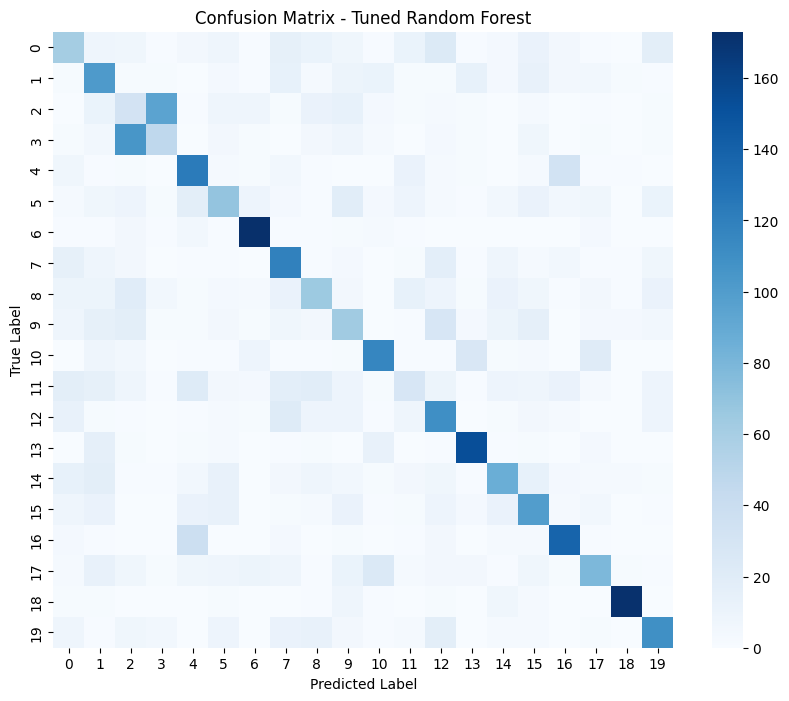

In [13]:
# Confusion matrix for tuned Random Forest
cm = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

            Feature  Importance
4      acousticness    0.134774
3       speechiness    0.131921
0      danceability    0.127245
7           valence    0.112080
2          loudness    0.107554
1            energy    0.104698
8             tempo    0.098452
5  instrumentalness    0.093088
6          liveness    0.090188


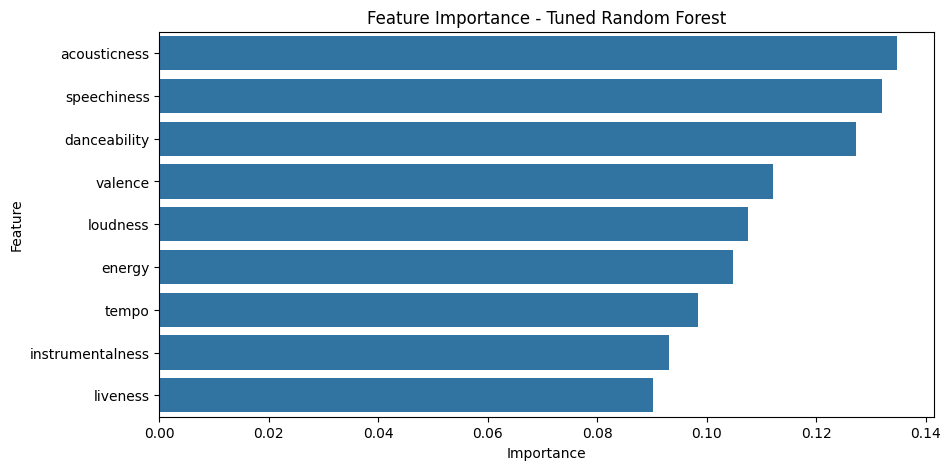

In [14]:
# Feature importance from tuned Random Forest
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(10,5))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title("Feature Importance - Tuned Random Forest")
plt.show()

In [15]:
# Final results table including tuned Random Forest
final_results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest", "SVM", "Tuned Random Forest"],
    "Accuracy": [baseline_acc, lr_acc, rf_acc, svm_acc, best_rf_acc],
    "Macro F1": [baseline_f1, lr_f1, rf_f1, svm_f1, best_rf_f1]
})

print(final_results.sort_values(by="Macro F1", ascending=False))

                 Model  Accuracy  Macro F1
2        Random Forest   0.48650  0.480286
4  Tuned Random Forest   0.48650  0.480286
3                  SVM   0.41225  0.399179
1  Logistic Regression   0.37050  0.347492
0             Baseline   0.05000  0.004762
